# Brownian motion

Een van de bekendste voorbeelden van botsende deeltjes in de natuur is Brownian motion.
Fijn gemalen pollen in water lijken te dansen in willekeurige richting.
Dit komt doordat de pollen worden geraakt door watermoleculen die in alle richtingen bewegen.
Omdat de pollen veel zwaarder zijn dan watermoleculen, dus de beweging van de pollen is veel langzamer en minder "intens" dan die van de watermoleculen.
Dit proces van willekeurige beweging door botsingen met kleinere deeltjes wordt Brownian motion genoemd en kunnen we simuleren op basis van ons (premature) botsingsmodel.
Daarbij kunnen we ook gebruik maken van de zojuist geleerde manier van tracking van deeltjes, waarbij we een zowel het zware bolletjes als een enkel deeltje kunnen volgen.

Let op!
We bestuderen hier nog geen thermische effecten, deze opdrachten zijn met name bedoeld om beter te begrijpen hoe het botsingsmodel in elkaar zit.

```{warning}
In dit notebook zitten delen waar ruimte is om code toe te voegen, maar waarbij je denkt... waarom dan?
In een latere opdracht moet je terug naar die cell en de juiste code toevoegen.
```

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Maken van de ParticleClass

class ParticleClass:
    # Het maken van het deeltje
    def __init__(self, m, v, r, R, c):
        self.m = m                         
        self.v = np.array(v, dtype=float)  
        self.r = np.array(r, dtype=float)  
        self.R = np.array(R, dtype=float)  
        self.c = c

    # Het updaten van de positie, eventueel met zwaartekracht
    def update_position(self):
        self.r += self.v * dt #+ 1/2 * a * dt**2  
              
    # Harde wand
    def boxcollision(self):
        if abs(self.r[0]) + self.R > Box_length: 
            self.v[0] = -self.v[0]                                  # Omdraaien van de snelheid
            self.r[0] = np.sign(self.r[0]) * (Box_length - self.R)  # Zet terug net binnen box                 
        if abs(self.r[1]) + self.R > Box_length: 
            self.v[1] = -self.v[1]     
            self.r[1] = np.sign(self.r[1]) * (Box_length - self.R) 
            
    @property
    def momentum(self):
        return self.m * self.v
    
    @property
    def kin_energy(self):
        return 1/2 * self.m * np.dot(self.v, self.v)

In [4]:
# Aanmaken van de randvoorwaarden en initiele condities
Box_size_0 = 10
Box_length_0 = Box_size_0/2
Box_length = Box_length_0     # De grootte van de box kan wijzigen!

# Particles
dt = 0.1
particles = []
N = 40
v_0 = 1

dt = 0.04

# Aanmaken van deeltjes

#Eerts 39 deeltjes aanmaken met een snelheid en kleine massa(1). 
for i in range(N-1):
    vx = np.random.uniform(-v_0,v_0) #random snelheid tussen -1 en 1
    vy = np.random.choice([-1, 1])*np.sqrt(v_0**2-vx**2)        
    pos = Box_length_0*np.random.uniform(-1,1,2) #random positie in de box
    particles.append(ParticleClass(m=1.0, v=[vx, vy], r = pos, R=.5,c='blue')) #toevoegen particles aan particle array 

particles.append(ParticleClass(m=20.0, v=[0, 0], r = [0, 0], R=.5,c='red')) #40e particle toevoegen aan array


```{exercise} Brownian motion
:label: ex-brownian-1

Leg uit wat er in de laatste regel van bovenstaande script gebeurt.
Voeg voor deze regel goede metadata toe.
```

```{solution} ex-brownian-1
Er worden eerst 39 deeltjes gemaakt (N-1) met een snelheid van maximaal 1 en ze worden aan een van de twee ergens ide box geplaats. Dit zijn als het ware de water deeltjes. Daarna wordt er aan de particle array nog een laatste, 40e, particle toegvoegd. Deze met dezelfde  snelheid, maar eengrotere massa.
```

Er is een doos vol met deeltjes op willekeurige positie aangemaakt.
We willen kijken waar de deeltjes zijn terechtgekomen.
Hieronder staat dit weergegeven. 



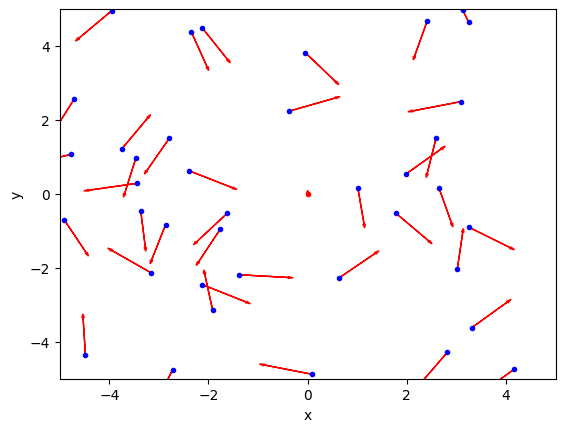

In [5]:
# Inspecteren van beginsituatie
plt.figure()

plt.xlabel('x')
plt.ylabel('y')

plt.xlim(-Box_length_0,Box_length_0)
plt.ylim(-Box_length_0,Box_length_0)


for particle, particle_object in enumerate(particles):
    plt.plot(particle_object.r[0],particle_object.r[1],color=particle_object.c,marker='.')
    plt.arrow(particle_object.r[0],particle_object.r[1], 
               particle_object.v[0],particle_object.v[1], 
               head_width=0.05, head_length=0.1, color='red')
plt.show()


```{exercise} 
:label: ex-brownian-2

Er staat ook code met comments ervoor, wat doet deze code? 
Check je antwoord door de comments weg te halen.
Hoe wordt er voor gezorgd dat de snelheid van elk deeltje gelijk is?
```

```{solution} ex-brownian-2
Er wordtt een pijl geplot bij de deeltjes die de kant op wijst van de snelheid. Eerst wordt een x snelheid random gegeven in de code die de deeltjes plot. Vervolgens wordt de y snelheid zo gegeven aan die deeltjes zodat de totale snelheid 1 is. Dit gebeurd door middel van pythagoras (x en y staan loodrecht op elkaar natuurlijk).
```

We gaan nu de functies van de simulatie weer aanroepen:

In [6]:
# Het bepalen of er een botsing plaats vindt
def collide_detection(self, other):
    dx = self.r[0] - other.r[0]
    dy = self.r[1] - other.r[1]
    rr = self.R + other.R
    return  dx**2+dy**2 < rr**2 
        
def particle_collision(p1: ParticleClass, p2: ParticleClass):
    """ past snelheden aan uitgaande van overlap """
    m1, m2 = p1.m, p2.m
    delta_r = p1.r - p2.r
    delta_v = p1.v - p2.v
    dot_product = np.dot(delta_r, delta_v)
    
    # Als deeltjes van elkaar weg bewegen dan geen botsing
    if dot_product >= 0: # '='-teken voorkomt ook problemen als delta_r == \vec{0}
        return
    
    distance_squared = np.dot(delta_r, delta_r) 
    # Botsing oplossen volgens elastische botsing in 2D
    p1.v -= 2 * m2 / (m1 + m2) * dot_product / distance_squared * delta_r
    p2.v += 2 * m1 / (m1 + m2) * dot_product / distance_squared * delta_r

def handle_collisions(particles):
#your code/answer
    """ alle onderlinge botsingen afhandelen voor deeltjes in lijst """
    botsing=0
    num_particles = len(particles)
    for i in range(num_particles):
        for j in range(i+1, num_particles):
            if collide_detection(particles[i], particles[j]):
                particle_collision(particles[i], particles[j])
                botsing=botsing+1 #botsing counter omhoog
    return botsing
#your code/answer


In onderstaande code geven we de code voor de simulatie en volgen we de positie van het zware deeltje. 

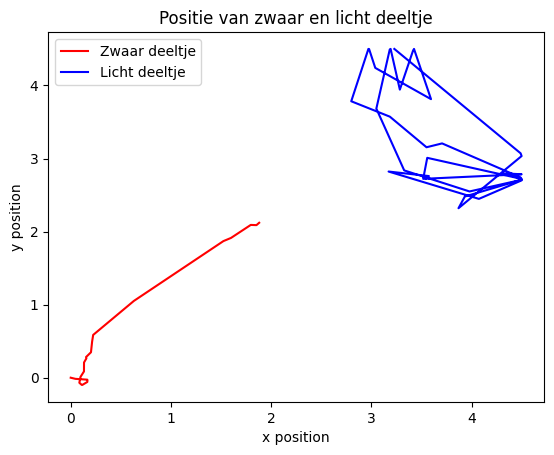

In [7]:
# tracken van het zware deeltje
track_x_z = []
track_y_z = []

#tracken van het lichte deeltje
track_x_l=[]
track_y_l=[]

#botsing array en aantal
botsingen=0
botsingen_array=[]

#Tijd array maken
dt_array=[]
#your code/answer

#your code/answer

for i in range(400):
#your code/answer
    
    for p in particles:
        p.update_position()    # Update positie        
        p.boxcollision()         # Wandbotsing werkt per deeltje

    #botsingen afhandelen en het aantal tellen
    botsingen=handle_collisions(particles)
    	
#your code/answer
    #tracks voor zware deeltje
    track_x_z.append(particles[N-1].r[0]) 
    track_y_z.append(particles[N-1].r[1])

    #tracks voor lichte deeltje
    track_x_l.append(particles[0].r[0])
    track_y_l.append(particles[0].r[1])

    #array van botsingen
    botsingen_array.append(botsingen)

    #array voor tijd
    dt_array.append(i*dt)
#your code/answer

#plot van posities maken
plt.figure()
plt.plot(track_x_z,track_y_z,'r',label='Zwaar deeltje') #zwaar deeltje plot
plt.plot(track_x_l,track_y_l, 'b', label='Licht deeltje') #licht deeltje plot
plt.xlabel('x position')
plt.ylabel('y position')
plt.title('Positie van zwaar en licht deeltje')
plt.legend()
plt.show()

```{exercise} Brownian motion in beeld
:label: ex-brownian-3
- Draai de onderstaande simulatie een keer en bestudeer de output.
- Voeg zelf een tweede tracking toe van een licht deeltje en verbeter de plot.
- Wat zijn overeenkomsten en verschillen tussen de beweging van de twee deeltjes?
- Wat valt je op als je de simulatie een aantal keer runt?
```

```{solution} ex-brownian-3
Subvraag 3: Je ziet dat het lichte deeltje een veel grotere afstand aflegt en ook veel meer kronkelt dan het zware deeltje. Het zware deeltje blijft juis relatief rond de zelfde positie hier. Beide leggen ze lang niet de hele box af en zijn zie je dat ze in hun route wel wat lusjes maken.

subvraag 4:
Je ziet dat het zware deeltje veel minder kronkelt en soms quasi rechte lijnen maakt. Het ziet er meer uit als een normaal patroon. Het lichte is heel erg hoekig. Je ziet ook dat ze beide 'moeite' hebben om uit hun hoekje te komen.
```

We zouden gevoel willen krijgen voor het aantal botsingen dat per tijdseenheid plaatsvindt. 
Elke keer dat er een botsing plaatsvindt, zou de counter met 1 omhoog moeten gaan.
Idealiter wordt het aantal botsingen opgeslagen in een array zodat je het aantal botsingen als functie van de tijd kunt weergeven.

```{exercise}
Pas bovenstaand idee toe in de eerder gemaakte code.
Plot hieronder het aantal botsingen als functie van de tijd.
```

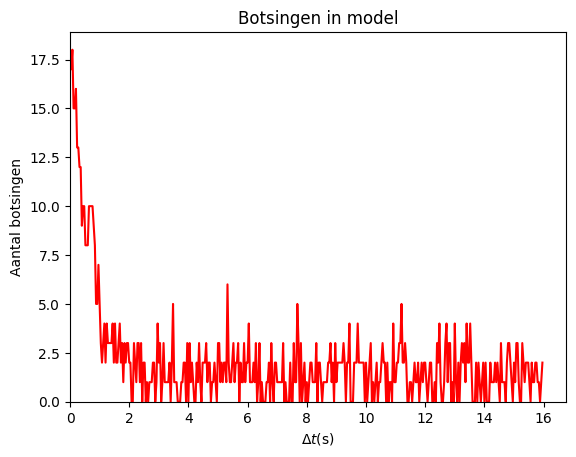

In [8]:
#plot van het aantal botsingen
plt.figure()
plt.plot(dt_array, botsingen_array,'r')
plt.title('Botsingen in model')
plt.xlabel('$\\Delta t$(s)')
plt.ylabel('Aantal botsingen')
plt.xlim(0,)
plt.ylim(0,)
plt.show()

```{warning} 🌶 Let op!
:icon: false
De onderstaande opdrachten vallen buiten de stof maar tellen mee als je excellent wilt behalen.
```

In zulke fysica modellen is de afgelegde weg (afstand tussen begin en eindpunt) van belang.
Deze afgelegde weg zegt iets over de snelheid van difussie.
Idealiter bekijken we een histogram.
Maar voor een histogram hebben we veel deeltjes nodig.



```{exercise} Afgelegde weg 🌶
:label: ex-brownian-4

- Maak een simulatie met 361 deeltjes, waarvan 1 zwaar deeltje.
- Houd rekening met de boxgrootte, deze moet mee schalen!
- Maak een histogram van de afgelegde weg voor alle deeltjes. 
- Geef de afgelegde weg van het grote deeltje duidelijk aan.
```


In [9]:
#Nieuwe basisvoorwaarden, nieuwe deeltjes maken

# Aanmaken van de randvoorwaarden en initiele condities, deze keer 361 deeltjes dus boks 9 keer zo groot
Box_size_0 = 30
Box_length_0 = Box_size_0/2
Box_length = Box_length_0     # De grootte van de box kan wijzigen!

# Particles
dt = 0.1
particles = []
N = 361 #Hier nu 361
v_0 = 1

dt = 0.04

# Aanmaken van deeltjes

#Eerts 360 deeltjes aanmaken met een snelheid en kleine massa(1). 
for i in range(N-1):
    vx = np.random.uniform(-v_0,v_0) #random snelheid tussen -1 en 1
    vy = np.random.choice([-1, 1])*np.sqrt(v_0**2-vx**2)        
    pos = Box_length_0*np.random.uniform(-1,1,2) #random positie in de box
    particles.append(ParticleClass(m=1.0, v=[vx, vy], r = pos, R=.5,c='blue')) #toevoegen particles aan particle array 

particles.append(ParticleClass(m=20.0, v=[0, 0], r = [0, 0], R=.5,c='red')) #361e particle toevoegen aan array



In [10]:
#beginposities
x_begin=[]
y_begin=[]

#eindposities
x_eind=[]
y_eind=[]

#afgelegde weg
afgelegde_weg=[]

#beginposities vastleggen
for i in range(N):
    x_begin.append(particles[i].r[0])
    y_begin.append(particles[i].r[1])

for i in range(400):
#your code/answer
    
    for p in particles:
        p.update_position()    # Update positie        
        p.boxcollision()         # Wandbotsing werkt per deeltje


    handle_collisions(particles)
    	
#your code/answer

#your code/answer

for i in range(N):
    x_eind.append(particles[i].r[0])
    y_eind.append(particles[i].r[1])
    
#verschil nemen
x_verschil=np.array(x_eind)-np.array(x_begin)
y_verschil=np.array(y_eind)-np.array(y_begin)

#weg berekenen
for i in range(N):
    verplaatsing=np.sqrt((x_verschil[i])**2+(y_verschil[i])**2)
    afgelegde_weg.append(verplaatsing)


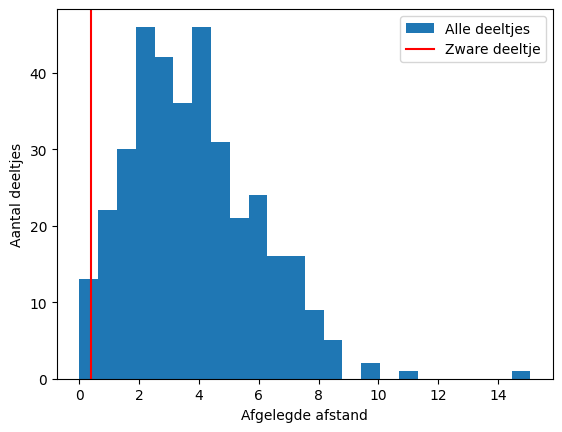

In [11]:
plt.figure()
plt.hist(afgelegde_weg, bins=24, label='Alle deeltjes')
plt.axvline(afgelegde_weg[N-1], c='r', label='Zware deeltje')
plt.legend()
plt.ylabel('Aantal deeltjes')
plt.xlabel('Afgelegde afstand')
plt.show()

En nu we toch bezig zijn met twee verschillende deeltjes.... 

We kunnen twee "groepen" van deeltjes aanmaken, elk  met een andere massa. Als we dan de zwaartekracht aan zetten, dan zouden we verwachten dat de lichtere deeltjes boven komen "drijven".

```{exercise} Onderzoek dit vermoeden 🌶
- maak daartoe de box 2x zo hoog als breed
- verdubbel het totaal aantal deeltjes
- zet een artificieel grote zwaartekracht aan
```

In [15]:
#Nieuwe particle class maken met zwaartekracht ditkeer

class ParticleClass:
    # Het maken van het deeltje
    def __init__(self, m, v, r, R, c):
        self.m = m                         
        self.v = np.array(v, dtype=float)  
        self.r = np.array(r, dtype=float)  
        self.R = np.array(R, dtype=float)  
        self.c = c

    # Het updaten van de positie, met zwaartekracht
    def update_position(self):
        self.r += self.v * dt +0.5 * a *dt**2

    def update_velocity(self):
        self.v+=a * dt
        
    # Harde wand, verandering voor nieuwe box met twee keer zo grote lengte
    def boxcollision(self):
        if abs(self.r[0]) + self.R > Box_width: 
            self.v[0] = -self.v[0]                                  # Omdraaien van de snelheid
            self.r[0] = np.sign(self.r[0]) * (Box_width - self.R)  # Zet terug net binnen box                 
        if abs(self.r[1]) + self.R > Box_length: 
            self.v[1] = -self.v[1]     
            self.r[1] = np.sign(self.r[1]) * (Box_length - self.R) 
            
    @property
    def momentum(self):
        return self.m * self.v
    
    @property
    def kin_energy(self):
        return 1/2 * self.m * np.dot(self.v, self.v)



In [16]:
#Nieuwe basisvoorwaarden, nieuwe deeltjes maken

# Aanmaken van de randvoorwaarden en initiele condities, deze keer 722 deeltjes
Box_size_0 = 30
Box_length = Box_size_0*2 #de lengte (y-as)
Box_width= Box_size_0 #De breedte (x-as)

# Particles
dt = 0.1
particles = []
N = 361 #Twee keer dit aantal
v_0 = 1
a=np.array([0,-5.0]) #zwaartekracht versnelling

dt = 0.04

# Aanmaken van deeltjes

#Eerts 361 deeltjes aanmaken met massa(1). 
for i in range(N):
    vx = np.random.uniform(-v_0,v_0) #random snelheid tussen -1 en 1
    vy = np.random.choice([-1, 1])*np.sqrt(v_0**2-vx**2)        
    x_pos = Box_width*np.random.uniform(-1,1) #random x positie in de box
    y_pos= Box_length*np.random.uniform(-1,1) #random y positie in de box
    particles.append(ParticleClass(m=1.0, v=[vx, vy], r = [x_pos, y_pos], R=.5,c='blue')) #toevoegen particles aan particle array 

#Nu 361 deeltjes aanmaken met massa 5:
for i in range(N):
    vx = np.random.uniform(-v_0,v_0) #random snelheid tussen -1 en 1
    vy = np.random.choice([-1, 1])*np.sqrt(v_0**2-vx**2)        
    x_pos = Box_width*np.random.uniform(-1,1) #random x positie in de box
    y_pos= Box_length*np.random.uniform(-1,1) #random y positie in de box
    particles.append(ParticleClass(m=40.0, v=[vx, vy], r = [x_pos, y_pos], R=.5,c='red')) #toevoegen particles aan particle array 

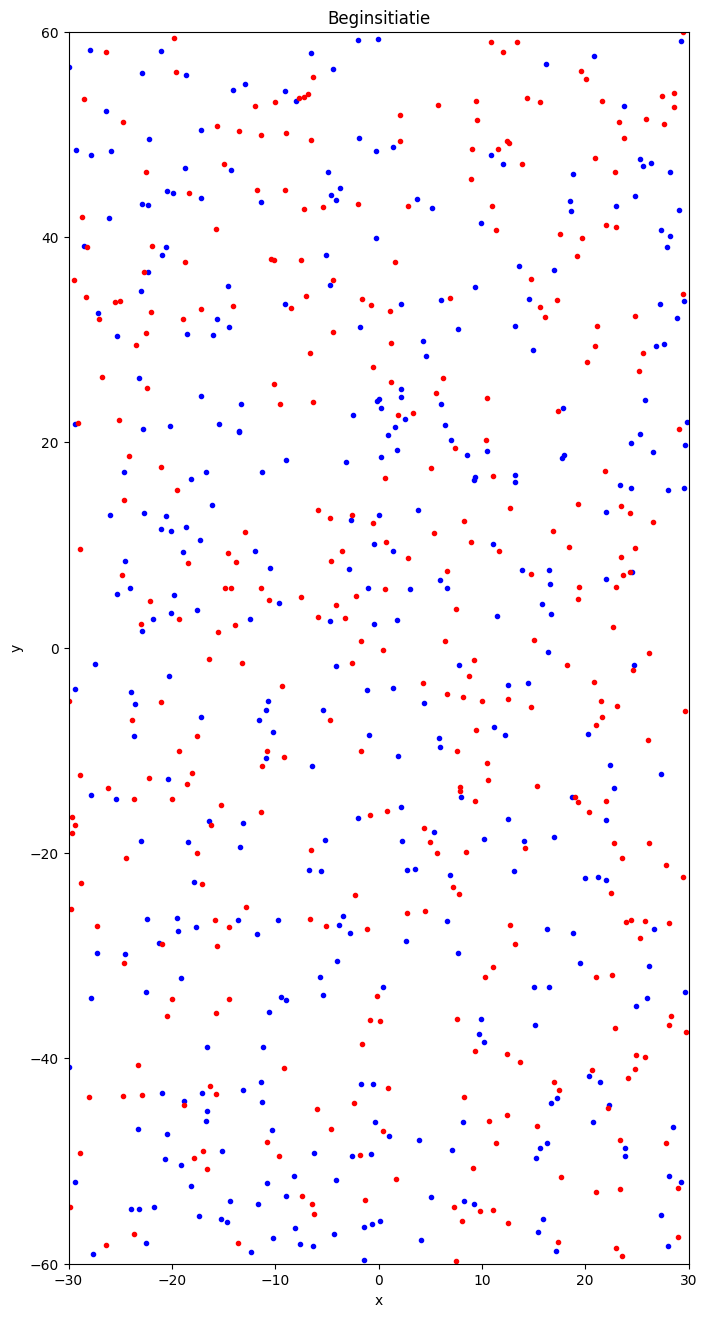

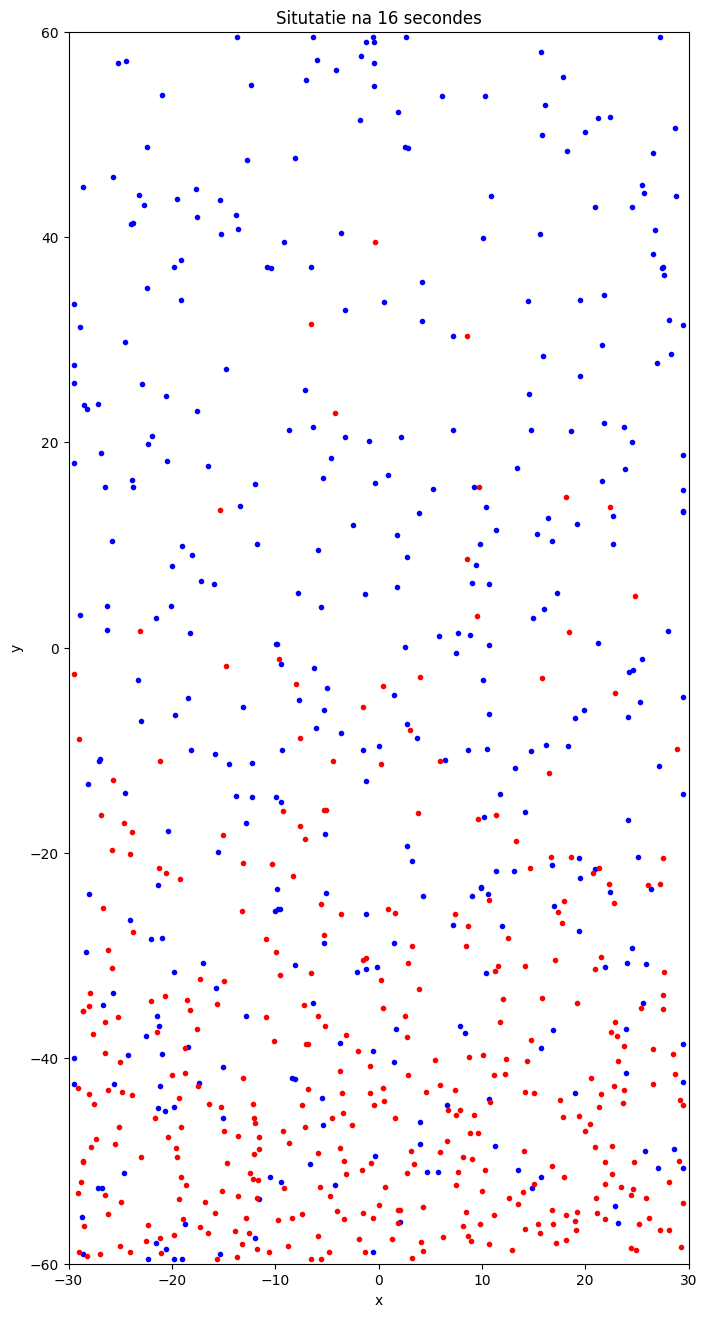

In [ ]:
# Plot van de beginsituatie
plt.figure(figsize=(8,16))

plt.xlabel('x')
plt.ylabel('y')

plt.xlim(-Box_width,Box_width)
plt.ylim(-Box_length,Box_length)


for particle, particle_object in enumerate(particles):
    plt.plot(particle_object.r[0],particle_object.r[1],color=particle_object.c,marker='.')
plt.title('Beginsitiatie')
plt.show()

for i in range(500):
    
    for p in particles:
        p.update_position()  
        p.update_velocity()  # Update positie        
        p.boxcollision()         # Wandbotsing werkt per deeltje

    #botsingen afhandelen
    handle_collisions(particles)
    	
#your code/answer
# Inspecteren van beginsituatie
plt.figure(figsize=(4,4))

plt.xlabel('x')
plt.ylabel('y')

plt.xlim(-Box_width,Box_width)
plt.ylim(-Box_length,Box_length)


for particle, particle_object in enumerate(particles):
    plt.plot(particle_object.r[0],particle_object.r[1],color=particle_object.c,marker='.')
plt.title('Situtatie na 16 secondes')
plt.show()
#your code/answer

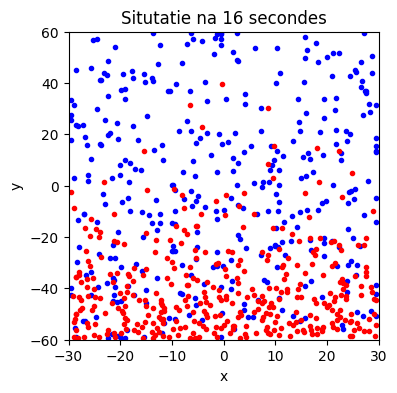

In [18]:
plt.figure(figsize=(4,4))

plt.xlabel('x')
plt.ylabel('y')

plt.xlim(-Box_width,Box_width)
plt.ylim(-Box_length,Box_length)


for particle, particle_object in enumerate(particles):
    plt.plot(particle_object.r[0],particle_object.r[1],color=particle_object.c,marker='.')
plt.title('Situtatie na 16 secondes')
plt.show()

40.0
